# Goal

Explore recurring chart patterns to identify long-term dynamics in popular music.

The analyses focus on chart re-entries to uncover temporal and seasonal patterns and to generate hypotheses for subsequent analyses using Spotify metadata.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Datasets

project_path = Path.cwd().parent
interim_path = project_path / 'data' / 'interim'

chart_history = pd.read_csv(interim_path/'uk_chart_history_clean.csv')
songs = pd.read_csv(interim_path/'songs.csv')
chart_statistics = pd.read_csv(interim_path/'chart_statistics.csv')

### Link Song Identifiers

Song identifiers are merged into the chart history to establish a stable relationship
between chart entries and song-based analyses.

In [3]:
chart_history = (chart_history
                 .merge(songs,
                        on=['Song', 'Artist'],
                        how='left')
                 )

chart_history = (chart_history[
    ['song_id',
     'Song',
     'Artist',
     'Position',
     'Last Week',
     'Peak',
     'Weeks on Chart',
     'Week']
])

chart_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 210882 entries, 0 to 210881
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   song_id         210837 non-null  float64
 1   Song            210882 non-null  str    
 2   Artist          210837 non-null  str    
 3   Position        210882 non-null  int64  
 4   Last Week       210882 non-null  str    
 5   Peak            210882 non-null  int64  
 6   Weeks on Chart  210882 non-null  int64  
 7   Week            210882 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 12.9 MB


In [4]:
songs.info()

<class 'pandas.DataFrame'>
RangeIndex: 36655 entries, 0 to 36654
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   song_id  36655 non-null  int64
 1   Song     36655 non-null  str  
 2   Artist   36655 non-null  str  
dtypes: int64(1), str(2)
memory usage: 859.2 KB


In [5]:
chart_statistics.info()

<class 'pandas.DataFrame'>
RangeIndex: 36655 entries, 0 to 36654
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   song_id               36655 non-null  int64
 1   Song                  36655 non-null  str  
 2   Artist                36655 non-null  str  
 3   peak_position         36655 non-null  int64
 4   total_chart_weeks     36655 non-null  int64
 5   observed_chart_weeks  36655 non-null  int64
 6   weeks_top_1           36655 non-null  int64
 7   weeks_top_10          36655 non-null  int64
 8   weeks_top_50          36655 non-null  int64
dtypes: int64(7), str(2)
memory usage: 2.5 MB


## Explore Last Week Status

The `Last Week` column contains information about a song's chart status in the
previous week.

This section explores the distribution of these status values and identifies
chart re-entries (`LW:RE`) for further analysis.

In [6]:
# Explore Last Week Entries

chart_history['Last Week'].value_counts().head(20)


Last Week
LW:New    36401
LW:RE     10297
LW:1       2139
LW:8       2139
LW:6       2138
LW:3       2138
LW:13      2138
LW:12      2138
LW:19      2138
LW:2       2137
LW:14      2137
LW:18      2136
LW:10      2136
LW:9       2136
LW:11      2136
LW:7       2135
LW:4       2134
LW:5       2133
LW:16      2133
LW:23      2133
Name: count, dtype: int64

In [7]:
## Identify Re-Entries

re_entry_count = (chart_history['Last Week'] == 'LW:RE').sum()
print(f'Number of chart re-entries: {re_entry_count}')

Number of chart re-entries: 10297


## Count Re-entries per Song

Re-entry events are aggregated by song to identify titles that repeatedly
returned to the charts over the observation period.

In [8]:
re_entries = (chart_history[chart_history['Last Week'] == 'LW:RE']
              .groupby('song_id')
              .size()
              .sort_values(ascending=False)
              )

re_entries.head(20)

song_id
24705.0    58
72.0       24
929.0      21
28523.0    20
12532.0    20
28337.0    19
26514.0    19
2738.0     19
12558.0    18
16733.0    18
27322.0    18
17554.0    17
30106.0    17
13822.0    17
28051.0    17
28356.0    17
26966.0    17
4775.0     17
28091.0    16
28056.0    16
dtype: int64

### Inspect the Most Frequent Re-entry

The song with the highest number of observed re-entries is identified to verify
the aggregation and provide an initial insight into long-term chart behaviour.

In [9]:
songs[songs['song_id'] == 24705]

,song_id,Song,Artist
24704,24705,MR BRIGHTSIDE,KILLERS


In [10]:
print(f'Songs with re-entries: {len(re_entries)}')
print(f'Share of songs with re-entries: {len(re_entries) / len(songs):.2%}')

Songs with re-entries: 6373
Share of songs with re-entries: 17.39%


## Create Re-entry History

All chart re-entry events are extracted into a separate dataset.

Only variables describing the individual re-entry event are retained, while
song-level statistics are handled separately in the chart statistics table.

This focused dataset serves as the basis for the following analyses of chart
positions, temporal patterns, and seasonal trends.

In [11]:
re_entry_history = (chart_history[
                    chart_history['Last Week'] == 'LW:RE'
                    ][['song_id',
                    'Song',
                    'Artist',
                    'Position',
                    'Last Week',
                    'Week']]
                    .copy()
                    )

re_entry_history.head()


,song_id,Song,Artist,Position,Last Week,Week
64,65.0,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,2 January 1983- 8 January 1983
74,75.0,LET'S GO TO BED,THE CURE,75,LW:RE,2 January 1983- 8 January 1983
89,90.0,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,2 January 1983- 8 January 1983
90,91.0,THE LOOK OF LOVE,ABC,91,LW:RE,2 January 1983- 8 January 1983
93,94.0,CRY BOY CRY,BLUE ZOO,94,LW:RE,2 January 1983- 8 January 1983


In [ ]:
## Explore Re-entry Years

re_entry_history['Year'] = (re_entry_history['Week'].str[-4:].astype(int))

re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Week,Year
64,65.0,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,2 January 1983- 8 January 1983,1983
74,75.0,LET'S GO TO BED,THE CURE,75,LW:RE,2 January 1983- 8 January 1983,1983
89,90.0,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,2 January 1983- 8 January 1983,1983
90,91.0,THE LOOK OF LOVE,ABC,91,LW:RE,2 January 1983- 8 January 1983,1983
93,94.0,CRY BOY CRY,BLUE ZOO,94,LW:RE,2 January 1983- 8 January 1983,1983


In [13]:
print(f'Re-entries in 1983: {len(re_entry_history[re_entry_history["Year"] == 1983])}')

print(f'Re-entries in 1983 and 1984: {len(re_entry_history[re_entry_history["Year"].between(1983, 1984)])}')

Re-entries in 1983: 75
Re-entries in 1983 and 1984: 223


In [ ]:
## Explore Re-entry Decades

re_entry_history['Decade'] = (re_entry_history['Year'] // 10) * 10

re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Week,Year,Decade
64,65.0,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,2 January 1983- 8 January 1983,1983,1980
74,75.0,LET'S GO TO BED,THE CURE,75,LW:RE,2 January 1983- 8 January 1983,1983,1980
89,90.0,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,2 January 1983- 8 January 1983,1983,1980
90,91.0,THE LOOK OF LOVE,ABC,91,LW:RE,2 January 1983- 8 January 1983,1983,1980
93,94.0,CRY BOY CRY,BLUE ZOO,94,LW:RE,2 January 1983- 8 January 1983,1983,1980


In [28]:
re_80s = len(re_entry_history[re_entry_history['Decade'] == 1980])

print(f'Re-entries in the 1980s: {re_80s}')

Re-entries in the 1980s: 974


### Explore Re-entry Positions

The chart positions of re-entry events are explored to understand where songs
typically return to the charts.

Summary statistics and the position distribution provide an initial overview of
this recurring chart pattern.

In [16]:
# Explore Re-Positions

re_entry_history['Position'].describe()

count    10297.000000
mean        80.851607
std         19.693226
min          1.000000
25%         74.000000
50%         87.000000
75%         95.000000
max        100.000000
Name: Position, dtype: float64

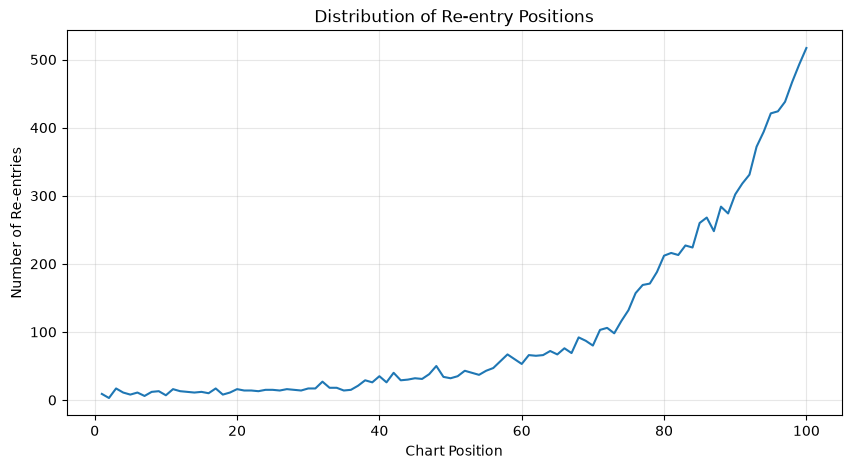

In [18]:
# Re-entry positions

re_position = (re_entry_history['Position']
               .value_counts()
               .sort_index()
               )

plt.figure(figsize=(10, 5))

plt.plot(re_position.index,
         re_position.values)

plt.title('Distribution of Re-entry Positions')
plt.xlabel('Chart Position')
plt.ylabel('Number of Re-entries')

plt.grid(alpha=0.3)

plt.show()

## Explore Re-entry Frequencies

The number of re-entries is calculated for each song to examine how frequently
songs return to the charts.

The resulting distribution highlights whether repeated chart re-entries are
common or represent exceptional cases.

In [19]:
re_counts = re_entries.value_counts().sort_index()
re_counts

1     4682
2     1000
3      303
4      128
5       73
6       41
7       35
8       26
9       17
10      10
11      15
12       6
13       9
14       5
15       1
16       4
17       7
18       3
19       3
20       2
21       1
24       1
58       1
Name: count, dtype: int64

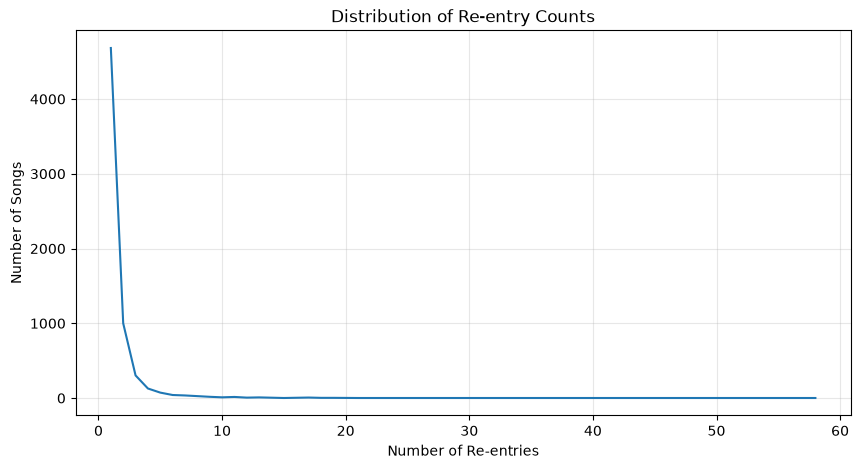

In [20]:
# Re-entry counts

plt.figure(figsize=(10, 5))

plt.plot(re_counts.index,
         re_counts.values)

plt.title('Distribution of Re-entry Counts')
plt.xlabel('Number of Re-entries')
plt.ylabel('Number of Songs')

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Most songs experience only a single chart re-entry, 
# while repeated re-entries are comparatively rare. 
# A small number of songs represent extreme long-term outliers.

### Identify Songs with Frequent Re-entries

Songs with the highest number of chart re-entries are identified to explore
which titles repeatedly return to the charts.

This provides an initial indication of long-term chart longevity.

In [23]:
top_re_songs = (re_entries
                .head(20)
                .rename('number_re_entries')
                .reset_index()
                .merge(songs,
                        on='song_id',
                        how='left')
                )

top_re_songs

,song_id,number_re_entries,Song,Artist
0,24705.0,58,MR BRIGHTSIDE,KILLERS
1,72.0,24,MERRY XMAS EVERYBODY,SLADE
2,929.0,21,THRILLER,MICHAEL JACKSON
3,28523.0,20,USE SOMEBODY,KINGS OF LEON
4,12532.0,20,STAY ANOTHER DAY,EAST 17
5,28337.0,19,ONE DAY LIKE THIS,ELBOW
6,26514.0,19,FAIRYTALE OF NEW YORK,POGUES FT KIRSTY MACCOLL
7,2738.0,19,MERRY CHRISTMAS EVERYONE,SHAKIN' STEVENS
8,12558.0,18,ALL I WANT FOR CHRISTMAS IS YOU,MARIAH CAREY
9,16733.0,18,I DON'T WANT TO MISS A THING,AEROSMITH


In [30]:
# Songs with frequent re-entries are predominantly long-lasting classics
# and seasonal titles, particularly Christmas songs.

### Explore Re-entry Activity over Time

The number of chart re-entries is aggregated by calendar year to examine how
re-entry activity changed throughout the observation period.

The resulting time series provides an initial overview of long-term temporal
patterns.

In [24]:
re_per_year = (re_entry_history
               .groupby('Year')
               .size()
               .rename('number_re_entries')
               )

re_per_year

Year
1983     75
1984    148
1985    182
1986    205
1987    130
1988    134
1989    100
1990     86
1991     66
1992     20
1993     24
1994    146
1995    291
1996    332
1997    334
1998    300
1999    376
2000    400
2001    348
2002    287
2003    272
2004    338
2005    204
2006    161
2007    262
2008    320
2009    315
2010    317
2011    426
2012    530
2013    498
2014    354
2015    243
2016    207
2017    269
2018    225
2019    211
2020    244
2021    240
2022    243
2023    307
2024    127
Name: number_re_entries, dtype: int64

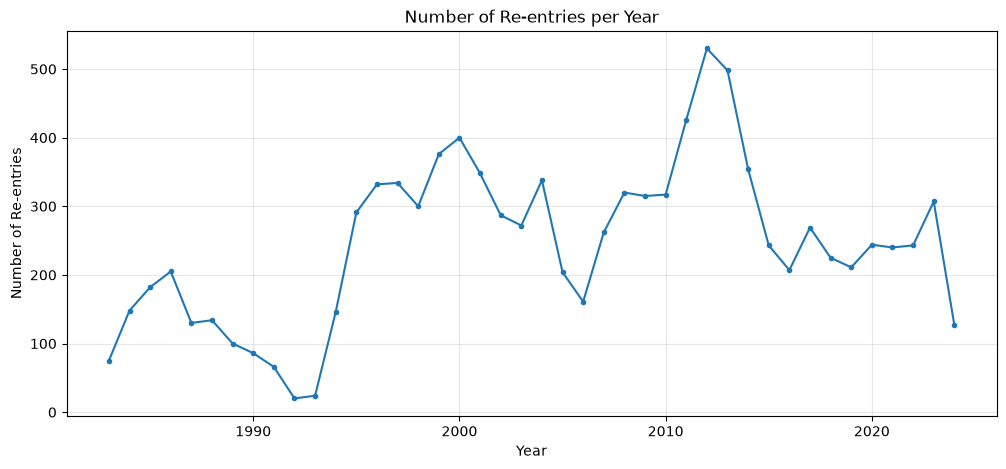

In [25]:
# Re-entries per Year

plt.figure(figsize=(12, 5))

plt.plot(re_per_year.index,
         re_per_year.values,
         marker='o',
         markersize=3)

plt.title('Number of Re-entries per Year')
plt.xlabel('Year')
plt.ylabel('Number of Re-entries')

plt.grid(alpha=0.3)

plt.show()

In [31]:
# The first years should be interpreted with caution because the observation
# period starts in 1983.

# Re-entry activity varies considerably over time. After a decline in the
# early 1990s, the number of re-entries increases substantially and reaches
# its highest levels around 2012.

# Technological changes may have influenced how songs re-enter the charts
# over time and represent a potential direction for further investigation.

### Explore Re-entry Seasonality

The chart week is used to derive the calendar month of each re-entry.

This enables an initial exploration of seasonal patterns in chart re-entries.

In [26]:
re_entry_history['Week'] = pd.to_datetime(re_entry_history['Week'].str.split('-').str[0],
                                            format='%d %B %Y')

re_entry_history['Month'] = (re_entry_history['Week'].dt.month)

re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Week,Year,Decade,Month
64,65.0,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,1983-01-02,1983,1980,1
74,75.0,LET'S GO TO BED,THE CURE,75,LW:RE,1983-01-02,1983,1980,1
89,90.0,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,1983-01-02,1983,1980,1
90,91.0,THE LOOK OF LOVE,ABC,91,LW:RE,1983-01-02,1983,1980,1
93,94.0,CRY BOY CRY,BLUE ZOO,94,LW:RE,1983-01-02,1983,1980,1


In [27]:
re_per_month = (re_entry_history
                .groupby('Month')
                .size()
                .rename('number_re_entries')
                )

re_per_month

Month
1     1494
2      755
3      717
4      703
5      674
6      748
7      836
8      718
9      659
10     758
11     831
12    1404
Name: number_re_entries, dtype: int64

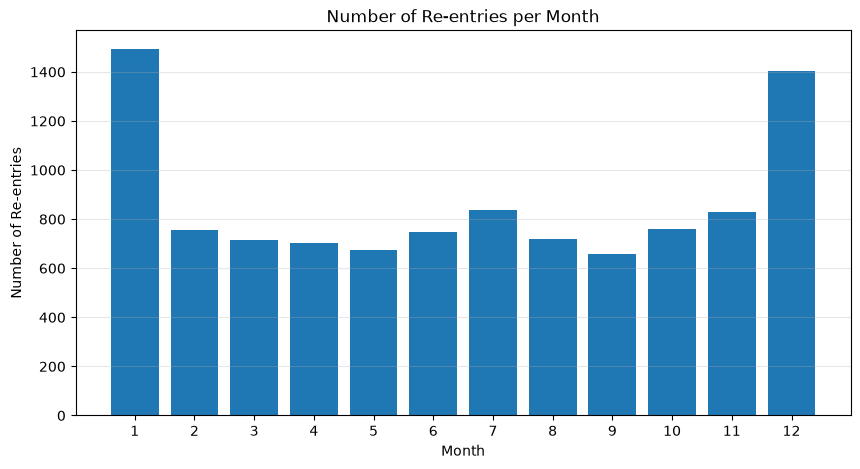

In [32]:
# Re-entries per Month

plt.figure(figsize=(10, 5))

plt.bar(re_per_month.index,
        re_per_month.values)

plt.title('Number of Re-entries per Month')
plt.xlabel('Month')
plt.ylabel('Number of Re-entries')

plt.xticks(range(1, 13))

plt.grid(axis='y', alpha=0.3)

plt.show()

In [33]:
# Re-entry activity shows a clear seasonal pattern. 
# January and December contain substantially more re-entries than the remaining months,
# indicating a strong seasonal influence on chart returns.

## Export Re-entry History

The enriched re-entry dataset is exported for reuse in subsequent analyses.

It contains all observed chart re-entry events together with the derived
temporal variables used throughout this notebook.

In [34]:
re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Week,Year,Decade,Month
64,65.0,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,1983-01-02,1983,1980,1
74,75.0,LET'S GO TO BED,THE CURE,75,LW:RE,1983-01-02,1983,1980,1
89,90.0,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,1983-01-02,1983,1980,1
90,91.0,THE LOOK OF LOVE,ABC,91,LW:RE,1983-01-02,1983,1980,1
93,94.0,CRY BOY CRY,BLUE ZOO,94,LW:RE,1983-01-02,1983,1980,1
